In [2]:
pip install requests beautifulsoup4 pandas tqdm

Note: you may need to restart the kernel to use updated packages.


# scraping for list of actors from popular films 

In [6]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd

base_url='https://letterboxd.com'
top_url='https://letterboxd.com/films/ajax/popular/size/small/'

headers={'User-Agent': 'Mozilla/5.0','Accept-Language': 'en-US,en;q=0.9'}
movie_data=[]
for page in range(1, 5): 
    url=f"{top_url}page/{page}/"
    res=requests.get(url, headers=headers)
    soup=BeautifulSoup(res.text, 'html.parser')
    posters=soup.find_all('div', class_='film-poster')

    for poster in posters:
        slug=poster.get('data-target-link')
        if slug:
            movie_url= base_url+slug
            movie_res=requests.get(movie_url, headers=headers)
            movie_soup=BeautifulSoup(movie_res.text, 'html.parser')
            title_tag=movie_soup.find('h1', class_='headline-1')
            title=title_tag.text.strip() if title_tag else "N/A"
            cast_section=movie_soup.find('div', class_='cast-list')
            actors=[]
            if cast_section:
                actor_tags=cast_section.find_all('a')
                for actor in actor_tags[:3]:  # Top 3 billed
                    actors.append(actor.text.strip())

            print(f"Scraped: {title}-{actors}")
            movie_data.append({'title': title, 'actors': actors})
            time.sleep(1) 

df = pd.DataFrame(movie_data)
df.to_csv('letterboxd_top_movies.csv', index=False)


Scraped: Barbie - ['Margot Robbie', 'Ryan Gosling', 'America Ferrera']
Scraped: Parasite - ['Song Kang-ho', 'Lee Sun-kyun', 'Cho Yeo-jeong']
Scraped: Interstellar - ['Matthew McConaughey', 'Anne Hathaway', 'Michael Caine']
Scraped: Fight Club - ['Edward Norton', 'Brad Pitt', 'Helena Bonham Carter']
Scraped: La La Land - ['Ryan Gosling', 'Emma Stone', 'John Legend']
Scraped: Everything Everywhere All at Once - ['Michelle Yeoh', 'Stephanie Hsu', 'Ke Huy Quan']
Scraped: Oppenheimer - ['Cillian Murphy', 'Emily Blunt', 'Matt Damon']
Scraped: Whiplash - ['Miles Teller', 'J.K. Simmons', 'Paul Reiser']
Scraped: Pulp Fiction - ['John Travolta', 'Samuel L. Jackson', 'Uma Thurman']
Scraped: Joker - ['Joaquin Phoenix', 'Robert De Niro', 'Zazie Beetz']
Scraped: Dune - ['Timothée Chalamet', 'Rebecca Ferguson', 'Oscar Isaac']
Scraped: The Substance - ['Demi Moore', 'Margaret Qualley', 'Dennis Quaid']
Scraped: Get Out - ['Daniel Kaluuya', 'Allison Williams', 'Catherine Keener']
Scraped: Spider-Man: In

# calculating which actors appear the most in the list to get Alist actors 

In [51]:
from collections import Counter
import ast
df= pd.read_csv('letterboxd_top_movies.csv')

#converting list of actors back to actual list
df['actors']=df['actors'].apply(ast.literal_eval)
# counting actors appearances 
all_actors=[actor for actors in df['actors'] for actor in actors]
actor_counts=Counter(all_actors)
#turning into dataframe and saaving 
actor_df=pd.DataFrame(actor_counts.items(), columns=['actor', 'appearances'])
actor_df=actor_df.sort_values(by='appearances', ascending=False)
actor_df.to_csv('star_actors.csv', index=False)


print(actor_df.head(100))  # showing top 100 actors that appewred the most

                 actor  appearances
58   Leonardo DiCaprio           11
105        Emma Watson           10
205       Rupert Grint            8
204   Daniel Radcliffe            8
68        Mark Ruffalo            8
..                 ...          ...
423        Adam Driver            2
141      Toni Collette            2
137       Kevin Spacey            2
453       Rachel Weisz            2
260       Eddie Murphy            2

[100 rows x 2 columns]


# scraping forbes for highest paid actors 

In [213]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url="https://www.forbes.com/sites/mattcraig/2025/02/28/the-highest-paid-actors-of-2024/"

headers={"User-Agent": "Mozilla/5.0"}
#sending a get request to the url
response=requests.get(url, headers=headers)
# checming if the request was successful
if response.status_code==200:
    #parse the content of the page
    soup=BeautifulSoup(response.text, "html.parser")
    #finding all the h2 tags, which contain the actor names on the website 
    h2_tags=soup.find_all("h2")
    #exctracting the actors names 
    actor_names=[]
    for tag in h2_tags:
        name=tag.get_text(strip=True)
        if name and not name.lower().startswith("forbes"):
            actor_names.append(name)
    

    actors_df=pd.DataFrame(actor_names, columns=["Actor Name"])
    print(actors_pay_df)

                          Actor Name
0                  #1.Dwayne Johnson
1   $88 million ($103 million gross)
2                   #2.Ryan Reynolds
3   $85 million ($100 million gross)
4                     #3. Kevin Hart
5   $81 million ($108 million gross)
6                  #4.Jerry Seinfeld
7    $60 million ($70 million gross)
8                    #5.Hugh Jackman
9    $50 million ($66 million gross)
10                     #6. Brad Pitt
11   $32 million ($42 million gross)
12                 #7.George Clooney
13   $31 million ($37 million gross)
14                  #8.Nicole Kidman
15   $31 million ($41 million gross)
16                   #9.Adam Sandler
17   $26 million ($35 million gross)
18                    #10.Will Smith
19   $26 million ($30 million gross)
20              #11.Mariska Hargitay
21   $25 million ($29 million gross)
22                #12.Channing Tatum
23   $24 million ($28 million gross)
24                 #13.Jason Statham
25   $24 million ($25 million gross)
2

# cleaning forbes data

In [215]:
import re

#making it so it only keeps the names (names start with a rank with #)
actors_df=actors_df[actors_df['Actor Name'].str.startswith('#')]
#now getting rid of the rank park 
def clean_name(text):
    match=re.search(r"#\d+\.\s*(.*)", text)
    return match.group(1).strip() if match else text

actors_df['Actor Name']=actors_df['Actor Name'].apply(clean_name)

print(actors_df)



            Actor Name
0       Dwayne Johnson
2        Ryan Reynolds
4           Kevin Hart
6       Jerry Seinfeld
8         Hugh Jackman
10           Brad Pitt
12      George Clooney
14       Nicole Kidman
16        Adam Sandler
18          Will Smith
20    Mariska Hargitay
22      Channing Tatum
24       Jason Statham
26       Mark Wahlberg
28          Matt Damon
30           John Cena
32   Denzel Washington
34     Jake Gyllenhaal
36  Scarlett Johansson
38     Joaquin Phoenix


# combining the lists of actors 


In [186]:
#combining the actor name columns 
combined_names=pd.concat([actors_pay_df['Actor Name'], actor_df['actor']])
#dropping duplictaes because the highest paid actors are probably in the popular movies 
unique_actor_names = combined_names.drop_duplicates().reset_index(drop=True)
#creating new data frame 
final_actor_df = pd.DataFrame(unique_actor_names, columns=["Actor Name"])


final_actor_df.to_csv("combined_actor_names.csv", index=False)
print(final_actor_df.head(150))


         Actor Name
0    Dwayne Johnson
1     Ryan Reynolds
2        Kevin Hart
3    Jerry Seinfeld
4      Hugh Jackman
..              ...
145  Jack Nicholson
146     Ethan Hawke
147     Ben Affleck
148  Morgan Freeman
149  Robin Williams

[150 rows x 1 columns]


# only keeping top 100 actors

In [220]:
#im only keeping the top 100 actors (forbes list is at the top), to limit it only to the biggest 100 stars 
star_actors_df = final_actor_df.head(100)

print(star_actors_df)

#saving to csv
star_actors_df.to_csv('100_star_actors.csv', index=False)


          Actor Name
0     Dwayne Johnson
1      Ryan Reynolds
2         Kevin Hart
3     Jerry Seinfeld
4       Hugh Jackman
..               ...
95    Carey Mulligan
96      Cameron Diaz
97       Amy Poehler
98      Pedro Pascal
99  Carrie-Anne Moss

[100 rows x 1 columns]


# merging list of actors with a cast and crew csv 

In [225]:
cast_df=pd.read_csv("cast_crew.csv")  # contains 'title' and 'cast'
stars_df=pd.read_csv("100_star_actors.csv")  # contains 'actor'

# make actor column into a list
star_actors=stars_df['Actor Name'].tolist()
#function to find stars in a 'cast'
def find_stars(cast_string, star_list):
    found_stars=[]
    for star in star_list:
        if star in cast_string:
            found_stars.append(star)
    return ", ".join(found_stars)

cast_df['stars_in_movie']=cast_df['cast'].apply(lambda x: find_stars(str(x), star_actors))

#choosing just rows that do have stars
starred_movies=cast_df[cast_df['stars_in_movie'] != ""]

starred_movies[['title', 'stars_in_movie']].to_csv("movies_with_star_actors.csv", index=False)
starred_movies.head(200)


,movie_id,title,cast,crew,stars_in_movie
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...","Sigourney Weaver, Sam Worthington"
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...","Tom Holland, Johnny Depp"
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...","Ralph Fiennes, Dave Bautista, Christoph Waltz"
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...","Christian Bale, Liam Neeson, Joseph Gordon-Lev..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",Willem Dafoe
...,...,...,...,...,...
317,76758,The Flowers of War,"[{""cast_id"": 2, ""character"": ""John Miller"", ""c...","[{""credit_id"": ""52fe494bc3a368484e1244b5"", ""de...",Christian Bale
319,9890,The Stepford Wives,"[{""cast_id"": 19, ""character"": ""Joanna Eberhart...","[{""credit_id"": ""52fe4541c3a36847f80c3eff"", ""de...","Nicole Kidman, Matthew Broderick"
320,855,Black Hawk Down,"[{""cast_id"": 20, ""character"": ""SSgt. Matt Ever...","[{""credit_id"": ""52fe4282c3a36847f8024871"", ""de...","Tom Hardy, Ewan McGregor"
322,18,The Fifth Element,"[{""cast_id"": 5, ""character"": ""Korben Dallas"", ...","[{""credit_id"": ""52fe420fc3a36847f8000c09"", ""de...",Gary Oldman


# checking which movies dont have stars

In [229]:
# Filter rows where 'stars_in_movie' is empty
no_star_movies=cast_df[cast_df['stars_in_movie'] == ""]

# Display the result
no_star_movies[['title']].head(300)  # or change the number to view more


,title
6,Tangled
9,Batman v Superman: Dawn of Justice
11,Quantum of Solace
14,Man of Steel
21,Robin Hood
...,...
657,Resident Evil: Retribution
660,Proof of Life
663,We Are Marshall
664,Hudson Hawk


# checking the ratio of movies with stars to movies without stars

In [235]:
#count rows where 'stars_in_movie' is empty
num_empty=cast_df[cast_df['stars_in_movie']==""].shape[0]
#count rows where 'stars_in_movie' is not empty
num_non_empty=cast_df[cast_df['stars_in_movie']!= ""].shape[0]

print(f"no star actors: {num_empty}")
print(f"at least one star actor: {num_non_empty}")


no star actors: 3426
at least one star actor: 1377


In [67]:
starred_movies=pd.read_csv('cleaned_movies_with_star_actors.csv')
movie_info=pd.read_csv('success_metrics.csv')
#removing duplicates as there were some for some reason
starred_movies=starred_movies.drop_duplicates(subset=['title'])
movie_info=movie_info.drop_duplicates(subset=['title'])
#performing  an inner join on the 'title' column
merged_df=pd.merge(starred_movies, movie_info, on='title', how='right')

#removing irrelevant columns
merged_df=merged_df.drop(columns=['url', 'release_date'], errors='ignore')

#saving to a new csv
merged_df.to_csv('merged_movies.csv', index=False)

# Display the first few rows to check
merged_df.head(200)



,title,stars_in_movie,critic_score,audience_score,awards_all,nomination_count,award_count,awards_won,awards_nominated,worldwide_gross
0,Love Story,NaN,63.0,75.0,Oscars - ACTOR(Nominated)\nOscars - ACTOR IN A...,14,6,Oscars - MUSIC (Original Score)(Won)\nGolden G...,Oscars - ACTOR(Nominated)\nOscars - ACTOR IN A...,136397186.0
1,Airport,NaN,75.0,54.0,Oscars - ACTRESS IN A SUPPORTING ROLE(Won)\nOs...,14,2,Oscars - ACTRESS IN A SUPPORTING ROLE(Won)\nGo...,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...,100489150.0
2,M*A*S*H,NaN,84.0,83.0,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...,16,3,Oscars - WRITING (Screenplay--based on materia...,Oscars - ACTRESS IN A SUPPORTING ROLE(Nominate...,81600193.0
3,Patton,NaN,91.0,93.0,Oscars - ACTOR(Won)\nOscars - ART DIRECTION(Wo...,13,8,Oscars - ACTOR(Won)\nOscars - ART DIRECTION(Wo...,Oscars - CINEMATOGRAPHY(Nominated)\nOscars - M...,62500000.0
4,The Aristocats,NaN,64.0,70.0,NaN,0,0,NaN,NaN,191000000.0
...,...,...,...,...,...,...,...,...,...,...
195,The New Land,NaN,100.0,86.0,Oscars - FOREIGN LANGUAGE FILM(Nominated),1,0,NaN,Oscars - FOREIGN LANGUAGE FILM(Nominated),NaN
196,Frogs,NaN,28.0,24.0,NaN,0,0,NaN,NaN,NaN
197,Silent Running,NaN,71.0,66.0,NaN,0,0,NaN,NaN,NaN
198,Godzilla vs. Gigan,NaN,67.0,48.0,NaN,0,0,NaN,NaN,NaN


# creating a binary variable for whether a movie has a star actor

In [71]:

merged_df['star_actor_binary']=merged_df['stars_in_movie'].apply(lambda x: 1 if pd.notnull(x) and str(x).strip() != "" else 0)
print(merged_df[['title', 'star_actor_binary']].head())


            title  star_actor_binary
0      Love Story                  0
1         Airport                  0
2         M*A*S*H                  0
3          Patton                  0
4  The Aristocats                  0


# box plot (used in blog)

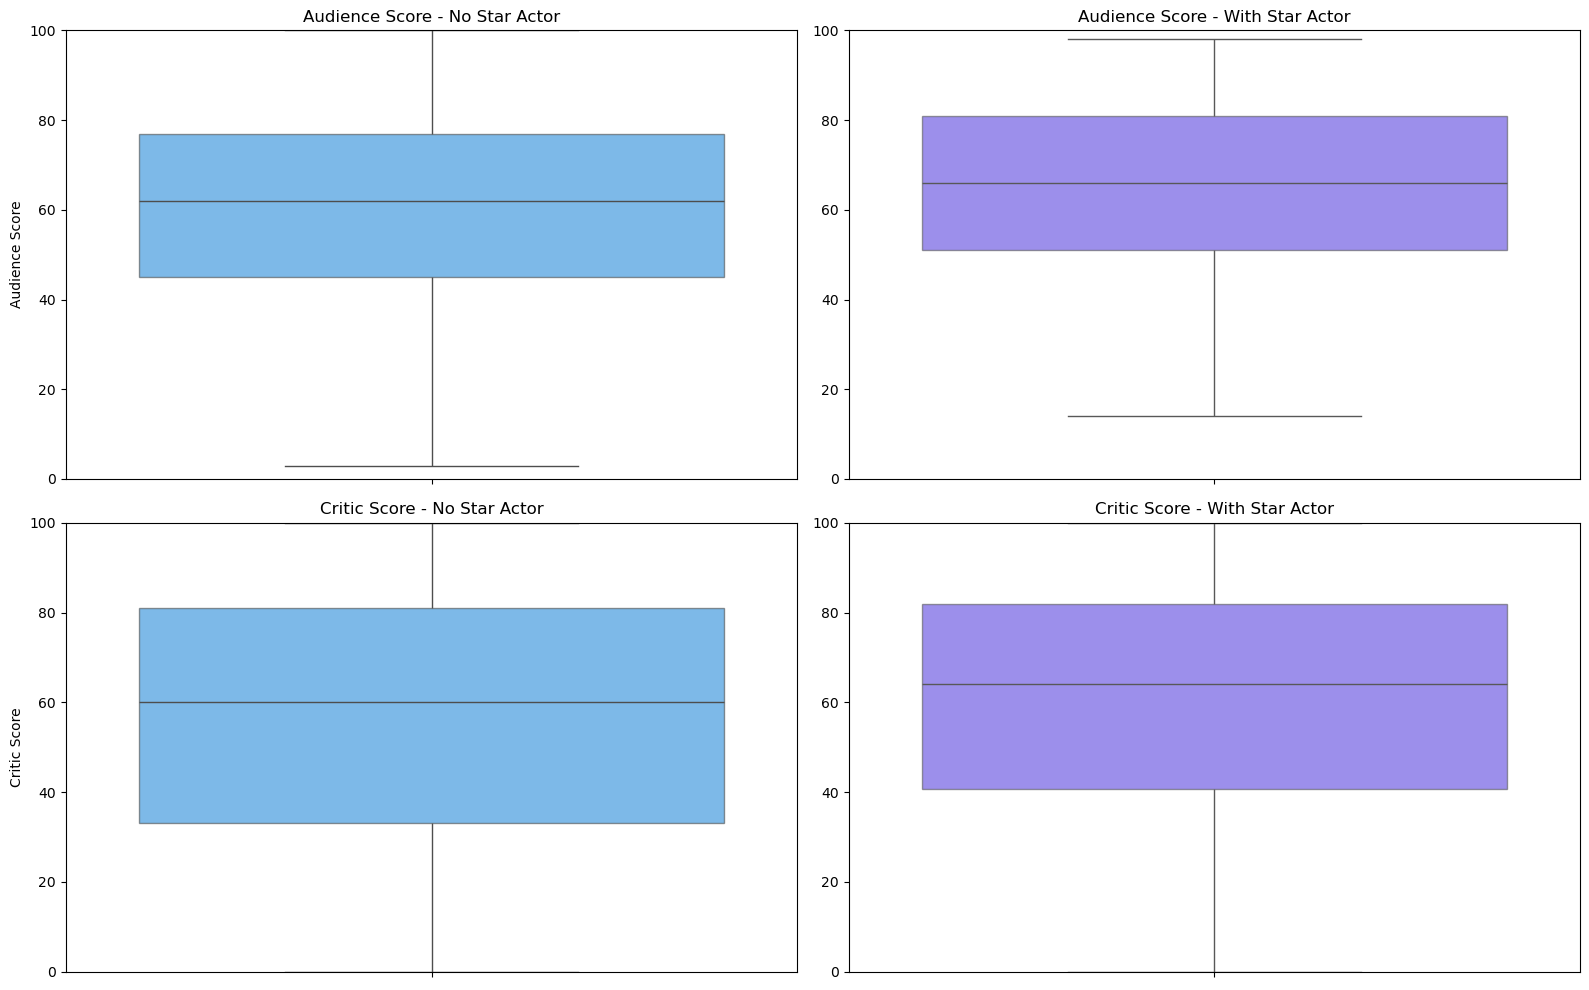

In [245]:
import seaborn as sns
import matplotlib.pyplot as plt

#setting figure
plt.figure(figsize=(16, 10))

# 1. audience score no star actor
plt.subplot(2, 2, 1)
sns.boxplot(y='audience_score', data=merged_df[merged_df['star_actor_binary']==0], color="#098FF7", boxprops=dict(alpha=0.6))
plt.title('Audience Score - No Star Actor')
plt.ylim(0, 100)
plt.ylabel('Audience Score')

# 2. audience score with star actor
plt.subplot(2, 2, 2)
sns.boxplot(y='audience_score', data=merged_df[merged_df['star_actor_binary']==1], color="#472BF9", boxprops=dict(alpha=0.6))
plt.title('Audience Score - With Star Actor')
plt.ylim(0, 100)
plt.ylabel('')

# 3.Critic Score No Star Actor
plt.subplot(2, 2, 3)
sns.boxplot(y='critic_score', data=merged_df[merged_df['star_actor_binary']==0], color="#098FF7", boxprops=dict(alpha=0.6))
plt.title('Critic Score - No Star Actor')
plt.ylim(0, 100)
plt.ylabel('Critic Score')

# 4. Critic Score - With Star Actor
plt.subplot(2, 2, 4)
sns.boxplot(y='critic_score', data=merged_df[merged_df['star_actor_binary']==1], color="#472BF9", boxprops=dict(alpha=0.6))
plt.title('Critic Score - With Star Actor')
plt.ylim(0, 100)
plt.ylabel('')

plt.tight_layout()
plt.show()



# scatter plot

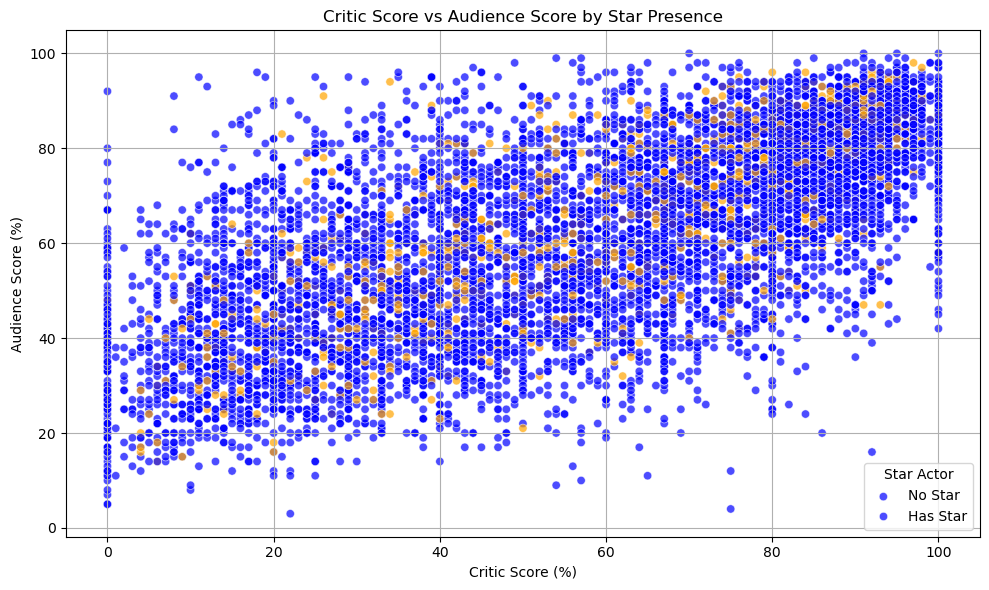

In [261]:

palette = {0: "blue", 1: "orange"}  # 0 = no star, 1 = has star

plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df,x='critic_score', y='audience_score',
    hue='star_actor_binary',
    palette=palette,
    alpha=0.7)

plt.title("Critic Score vs Audience Score by Star Presence")
plt.xlabel("Critic Score (%)")
plt.ylabel("Audience Score (%)")
plt.legend(title="Star Actor", labels=["No Star", "Has Star"])
plt.grid(True)
plt.tight_layout()
plt.show()


# making key stratisics (used in plot) 

In [265]:
#splitting the dataframe
with_star= merged_df[merged_df['star_actor_binary']==1]
without_star=merged_df[merged_df['star_actor_binary']==0]


summary_stats=pd.DataFrame({
    "Statistic": ["Mean", "Median", "Standard Deviation", "Minimum", "Maximum"],
    "Critic Score (Star)": [with_star['critic_score'].mean(),with_star['critic_score'].median(),with_star['critic_score'].std(),with_star['critic_score'].min(),with_star['critic_score'].max()],
    "Critic Score (No Star)": [without_star['critic_score'].mean(),without_star['critic_score'].median(),without_star['critic_score'].std(),without_star['critic_score'].min(),without_star['critic_score'].max()],
    "Audience Score (Star)": [with_star['audience_score'].mean(),with_star['audience_score'].median(),with_star['audience_score'].std(),with_star['audience_score'].min(),with_star['audience_score'].max()],
    "Audience Score (No Star)": [without_star['audience_score'].mean(),without_star['audience_score'].median(),without_star['audience_score'].std(),without_star['audience_score'].min(),without_star['audience_score'].max()],})

print(summary_stats)


            Statistic  Critic Score (Star)  Critic Score (No Star)  \
0                Mean            59.974684               56.123126   
1              Median            64.000000               60.000000   
2  Standard Deviation            25.137791               28.013163   
3             Minimum             0.000000                0.000000   
4             Maximum           100.000000              100.000000   

   Audience Score (Star)  Audience Score (No Star)  
0              65.006329                 60.631741  
1              66.000000                 62.000000  
2              18.554010                 20.207986  
3              14.000000                  3.000000  
4              98.000000                100.000000  


In [270]:
import statsmodels.api as sm
df_clean=merged_df[['worldwide_gross', 'critic_score', 'star_actor_binary']].dropna()
X=sm.add_constant(df_clean['star_actor_binary'])

model_box=sm.OLS(df_clean['worldwide_gross'], X).fit()
print(model_box.summary())

model_critic=sm.OLS(df_clean['critic_score'], X).fit()
print(model_critic.summary())


                            OLS Regression Results                            
Dep. Variable:        worldwide_gross   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     86.54
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           2.57e-20
Time:                        13:58:40   Log-Likelihood:                -61508.
No. Observations:                2990   AIC:                         1.230e+05
Df Residuals:                    2988   BIC:                         1.230e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.201e+08   4.36e+0